In [1]:
import cfe

# cfe.logger.setLevel("DEBUG")
cfe.logger.setLevel("INFO")

backend = "cfe_docker"
# backend = "conda"
cfe.settings.backend = backend

[10/17/2025 04:11:31] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

第一次从头运行结果保存ref, scvelo轨迹为pkl文件

                      WARNING  cell_1103 is not in '.obs.index', skip adding 'start_cell'                                                                                                               
                      INFO     method backend loaded: CFE Docker Backend: scvelo in docker image 'huangzhaoyang/scvelo:0.0.1'                                                                           
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
or is corrupted (e.g. due to subsetting). Consider recomputing with `pp.neighbors`.
computing terminal states
    identified 4 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities a

('pancreas',
 AnnData object with n_obs × n_vars = 500 × 27998
     obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
     uns: 'id', 'cfe', 'filename', 'clusters_colors'
     obsm: 'X_pca', 'X_umap'
     layers: 'spliced', 'unspliced', 'expression', 'counts')

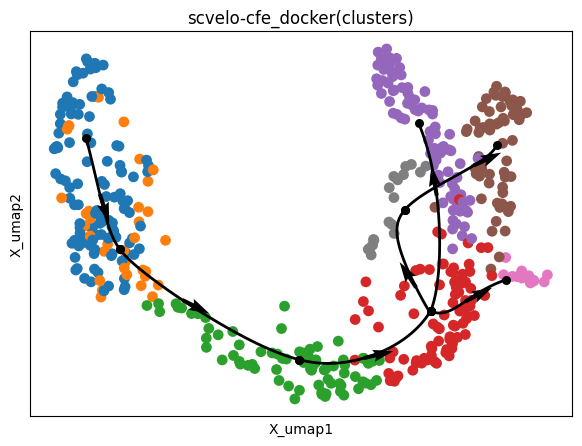

In [2]:
# data
fadata = cfe.data.read_pancrease(n_obs=500)

# method execute
parameters = {}
method = cfe.method.FateMethod(method_name="scvelo")
method.infer_trajectory(fadata, parameters)

# visualization
cfe.plot.plot_trajectory(fadata)

# save trajectory dict
fadata.write_trajectory_dict()

fadata.id, fadata

第二次从头运行结果palantir

[10/17/2025 04:11:40] WARNING  cell_1103 is not in '.obs.index', skip adding 'start_cell'                                                                                                               
                      INFO     method backend loaded: CFE Docker Backend: palantir in docker image 'huangzhaoyang/palantir:0.0.1'                                                                       
[10/17/2025 04:11:56] INFO     method infer trajectory successfully: CFE Docker Backend: palantir in docker image 'huangzhaoyang/palantir:0.0.1'                                                        


('pancreas',
 AnnData object with n_obs × n_vars = 500 × 27998
     obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
     uns: 'id', 'cfe', 'filename', 'clusters_colors'
     obsm: 'X_pca', 'X_umap'
     layers: 'spliced', 'unspliced', 'expression', 'counts')

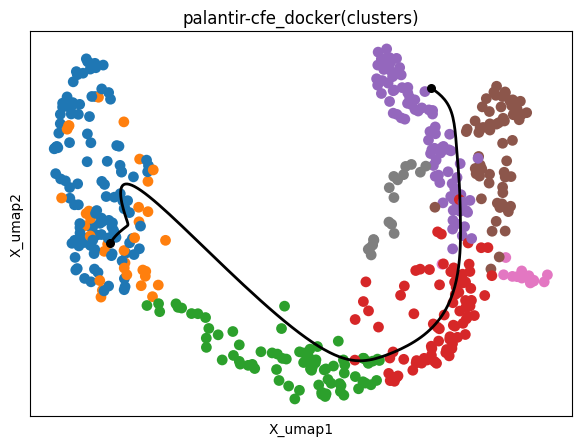

In [3]:
# data
fadata = cfe.data.read_pancrease(n_obs=500)
fadata.add_prior_information(start_cell="cell_000")

# method execute
parameters = {}
method = cfe.method.FateMethod(method_name="palantir")
method.infer_trajectory(fadata, parameters)

# visualization
cfe.plot.plot_trajectory(fadata)

# save trajectory dict
fadata.write_trajectory_dict()

fadata.id, fadata

基于第二次的结果，合并之前的ref和scvelo的轨迹文件，应该跳过ref，只保存scvelo

In [4]:
fadata.load_trajectory_dict()
fadata.get_all_model_name(parse=False)

['ref',
 '20251017_161140__palantir-cfe_docker__3HjH4Qpz0a',
 '20251017_161131__scvelo-cfe_docker__hZquaKYx7E']

保存整体并h5ad文件, 后续可视化并且多个轨迹同时可视化

In [5]:
fadata.write_h5ad("output.h5ad")